In [28]:
# imports

import numpy as np
import numpysane as nps
import cv2
from scipy.stats import qmc
from scipy.spatial.transform import Rotation
import mrcal
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import trange

In [22]:
# reference model

# TODO: PUT YOUR MODEL PATH HERE
CAMERAMODEL = Path("/workspace/assets/models/basler_kowa_sample.cameramodel").resolve()

model = mrcal.cameramodel(str(CAMERAMODEL))

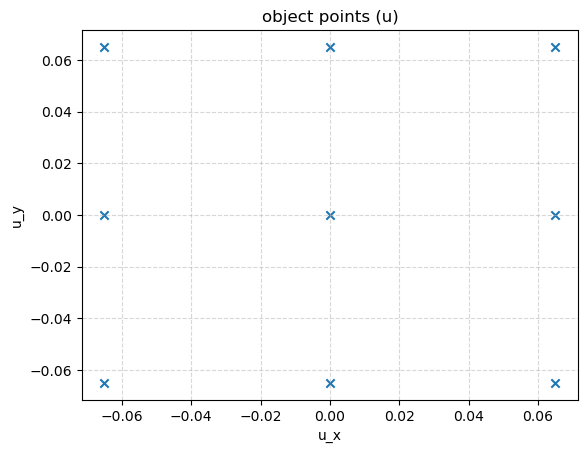

In [133]:
# object points (u_{x, y})

def make_grid_object(width, height, segments):
    x, y = np.meshgrid(np.linspace(-width/2, +width/2, segments), np.linspace(-height/2, +height/2, segments)) 
    return x.flatten(), y.flatten()

u_x, u_y = make_grid_object(0.13, 0.13, 3)
u = np.stack((u_x, u_y, np.zeros_like(u_x)), axis=-1)

plt.figure()
plt.scatter(u_x, u_y, marker='x')
plt.title("object points (u)")
plt.xlabel("u_x")
plt.ylabel("u_y")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [134]:
# projection utilities
# monocular PnP solve

def show_image_points(q, model):
    """Show image points `q` in (n,2) within image plane defined by `model`."""
    w, h = model.imagersize()

    plt.figure()
    plt.scatter(q[:, 0], q[:, 1], marker='x')
    plt.xlim(0, w)
    plt.ylim(0, h)
    plt.show()

def to_pinhole(q, model):
    """Unproject `q` in (n,2) to normalized image coordinates. Reproject via idealized pinhole model."""
    lensmodel, intrinsics = model.intrinsics()

    # extract core
    fx, fy, cx, cy = intrinsics[:4]
    K = np.array([[fx, 0, cx], [0, fy, cy], [0, 0, 1]], dtype=np.double)

    # normalized image coordinates (z=1)
    rays = mrcal.unproject(q, lensmodel, intrinsics)
    xy1 = rays / rays[:, 2:3]
    q_pinhole = (xy1 @ K.T)[:, :2]

    return K, np.ascontiguousarray(q_pinhole)
# rotation
    
def solve_pnp_mrcal(u, q, model, flags=cv2.SOLVEPNP_IPPE, refine=True):  
    K, q_pinhole = to_pinhole(q, model) 
    n, rvecs, tvecs, reproj_err = cv2.solvePnPGeneric(u, q_pinhole, K, None, flags=flags)

    if not refine or n == 0:
        return n, rvecs, tvecs, reproj_err

    solutions = []
    for rvec, tvec in zip(rvecs, tvecs):
        rvec, tvec = cv2.solvePnPRefineLM(u, q_pinhole, K, None, rvec, tvec)
        q_est, _ = cv2.projectPoints(u, rvec, tvec, K, None)
        residual = q_est.reshape(-1, 2) - q_pinhole
        rmse = np.sqrt(np.mean(np.sum(residual**2, axis=1)))
        solutions.append((rmse, rvec, tvec))
    
    solutions.sort(key=lambda x : x[0])
    reproj_err = np.array([[s[0]] for s in solutions])
    rvecs = tuple(s[1] for s in solutions)
    tvecs = tuple(s[2] for s in solutions)

    return n, rvecs, tvecs, reproj_err

In [135]:
# QMC

def sample_poses(model, m, dist_range, sigma_range, seed=0, max_facing_deg=80):
    """
    Generate 2^m poses using a Sobol sampler.
    Target's local +Z axis is its outward-facing normal.
    """
    w, h = model.imagersize()
    s = qmc.Sobol(d=7, scramble=True, seed=seed).random_base2(m)
    n = len(s)

    # pixel position
    q_center = s[:, :2] * [w, h]

    # distance, noise
    dist = dist_range[0] + s[:, 2] * (dist_range[1] - dist_range[0])
    sigma = sigma_range[0] + s[:, 3] * (sigma_range[1] - sigma_range[0])

    # translation
    rays = mrcal.unproject(q_center, *model.intrinsics(), normalize=True)
    t = rays * dist[:, None]

    # target normal points toward the camera
    n0 = -rays

    # Orthonormal tangent basis around n0
    ref = np.tile([0, 1, 0], (n, 1))
    ref[np.abs(n0[:, 1]) > 0.9] = [1., 0., 0.] # pick a better ref

    a = np.cross(ref, n0)
    a /= np.linalg.norm(a, axis=1, keepdims=True)
    b = np.cross(n0, a)

    # uniform solid-angle sampling within the facing cone
    cos_theta = 1 - s[:, 4] * (1 - np.cos(np.deg2rad(max_facing_deg)))
    sin_theta = np.sqrt(1 - cos_theta**2)

    phi = 2 * np.pi * s[:, 5]
    psi = 2 * np.pi * s[:, 6]

    # target normal (+Z axis) in camera coordinates
    z = (
        cos_theta[:, None] * n0
        + sin_theta[:, None] * (
            np.cos(phi)[:, None] * a
            + np.sin(phi)[:, None] * b
        )
    )

    # construct rotation matrices with arbitrary in-plane rotation
    x0 = a - np.sum(a * z, axis=1, keepdims=True) * z
    x0 /= np.linalg.norm(x0, axis=1, keepdims=True)
    y0 = np.cross(z, x0)

    x = np.cos(psi)[:, None] * x0 + np.sin(psi)[:, None] * y0
    y = np.cross(z, x)

    R = np.stack((x, y, z), axis=-1)

    facing = np.degrees(np.arccos(np.clip(cos_theta, -1, 1)))
    keep = np.isfinite(t).all(axis=1) & np.isfinite(R).all(axis=(1, 2))

    return {
        k: v[keep]
        for k, v in dict(
            q_center=q_center,
            dist=dist,
            R=R,
            t=t,
            sigma=sigma,
            facing=facing,
        ).items()
    }

def pose_error(R, t, R_est, t_est):
    # measure error of a pose estimate
    dR = R.T @ R_est
    rot = np.degrees(Rotation.from_matrix(dR).magnitude())
    return rot, np.linalg.norm(t - t_est)

def run_mc(model, u, S, seed=0):
    rng = np.random.default_rng(seed)
    w, h = model.imagersize()
    rows = []

    for i in trange(len(S["t"])):
        R, t, sigma = S["R"][i], S["t"][i], S["sigma"][i]

        row = dict(
            u=S["q_center"][i, 0], # pixel x
            v=S["q_center"][i, 1], # pixel y
            distance=S["dist"][i],
            cam_relative_deg=S["facing"][i],
            keypoint_stddev=sigma,
            rotation_deg=np.degrees(Rotation.from_matrix(R).magnitude()),
            failed=True
        )

        # obtain image points
        q = mrcal.project(u @ R.T + t, *model.intrinsics())
        inside = np.isfinite(q).all() and (q[:, 0] >= 0).all() and (q[:, 0] < w).all() \
                 and (q[:, 1] >= 0).all() and (q[:, 1] < h).all()

        row["valid"] = inside

        if inside:
            q_noisy = q + rng.normal(0, sigma, q.shape)

            try:
                n, rv, tv, err = solve_pnp_mrcal(u, q_noisy, model)
                err = np.asarray(err).ravel()

                if n > 0:
                    candidates = [(cv2.Rodrigues(r)[0], t.ravel()) for r, t in zip(rv, tv)]
                    errs = [pose_error(R, t, R_est, t_est) for R_est, t_est in candidates]

                    row.update(
                        R_err_deg=errs[0][0],
                        t_err=errs[0][1],
                        t_err_pct=100 * errs[0][1] / np.linalg.norm(t),
                        failed=False
                    )
            except cv2.error:
                pass

        rows.append(row)

    return pd.DataFrame(rows)

In [136]:
S = sample_poses(model, m=15, dist_range=(0.5, 6.0), sigma_range=(0.0, 3.0), max_facing_deg=85)

# valid rotation matrices
assert np.allclose(
    S["R"] @ S["R"].transpose(0, 2, 1),
    np.eye(3),
    atol=1e-12,
)

assert np.allclose(
    np.linalg.det(S["R"]),
    1.0,
    atol=1e-12,
)

# correct facing angles
rays = S["t"] / np.linalg.norm(S["t"], axis=1, keepdims=True)

facing = np.degrees(np.arccos(np.clip(
    -np.sum(S["R"][:, :, 2] * rays, axis=1),
    -1, 1
)))

assert np.allclose(facing, S["facing"], atol=1e-6)

df = run_mc(model, u, S)

100%|██████████| 32768/32768 [00:13<00:00, 2447.00it/s]


In [137]:
LIMITS = {
    "R_err_deg": 24,
    "t_err_pct": 16,
}

def plot_all(df, err, cols=("distance", "cam_relative_deg", "keypoint_stddev"), bins=20):
    d = df[~df.failed & df.valid]
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes = axes.ravel()

    max_err = LIMITS.get(err)

    for ax, c in zip(axes, cols):
        ax.scatter(d[c], d[err], s=2, alpha=0.15, c="gray")
        g = d.groupby(pd.cut(d[c], bins), observed=True)[err]
        mid = [iv.mid for iv in g.median().index]
        ax.plot(mid, g.median().values, "r-", label="median")
        ax.plot(mid, g.quantile(0.90).values, "b--", label="p90")
        ax.set_xlabel(c)
        ax.set_ylabel(err)
        if max_err:
            ax.set_ylim(0, max_err)
        ax.grid(True)

    axes[0].legend()
    plt.tight_layout()

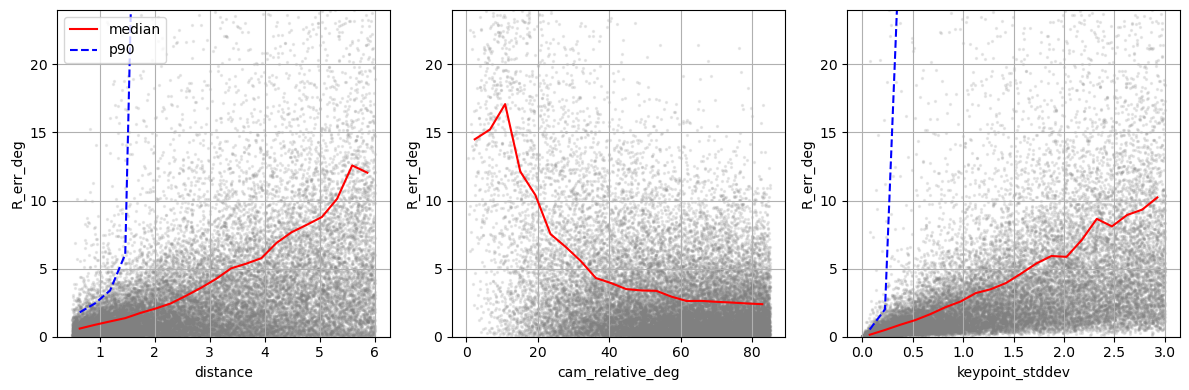

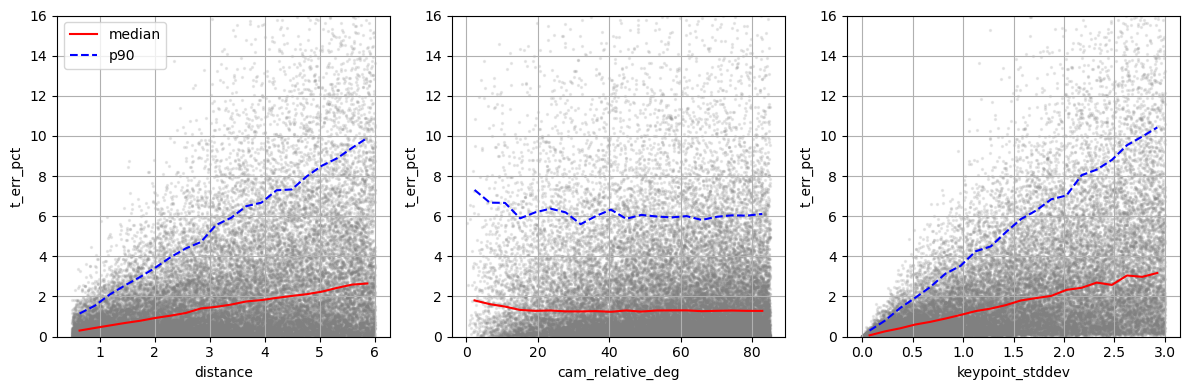

In [138]:
plot_all(df, "R_err_deg")
plot_all(df, "t_err_pct")